# Q1: Correcting for population stratification in GWAS with PCA

Starter template: load the data and check its shape.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Q1.data: tab-separated, 1000 individuals (rows) x 2001 columns
# columns snp_0 ... snp_1999 are genotypes (0/1/2), last column is the binary phenotype
df = pd.read_csv('data/Q1/Q1.data', sep='\t')
df.head()

,snp_0,snp_1,snp_2,snp_3,snp_4,snp_5,snp_6,snp_7,snp_8,snp_9,...,snp_1991,snp_1992,snp_1993,snp_1994,snp_1995,snp_1996,snp_1997,snp_1998,snp_1999,phenotype
0,0,2,2,2,2,1,2,1,2,2,...,2,0,2,0,1,1,1,0,1,1
1,0,1,1,2,1,2,1,2,2,2,...,2,1,2,1,2,2,0,1,2,1
2,0,2,2,1,2,2,0,2,2,1,...,1,1,2,1,0,2,1,1,0,1
3,1,1,1,2,1,1,2,2,2,2,...,2,0,2,1,1,2,0,1,0,1
4,0,2,1,1,2,1,1,2,2,2,...,1,0,1,2,1,1,1,0,1,1


In [3]:
X = df.iloc[:, :-1].values   # (1000, 2000) genotype matrix
y = df.iloc[:, -1].values    # (1000,) phenotype

print('X shape:', X.shape)
print('y shape:', y.shape)
print('genotype values:', np.unique(X))
print('phenotype values:', np.unique(y))
print('N individuals:', X.shape[0])
print('M SNPs:', X.shape[1])

X shape: (1000, 2000)
y shape: (1000,)
genotype values: [0 1 2]
phenotype values: [0 1]
N individuals: 1000
M SNPs: 2000


Part (a): Linear Regression 

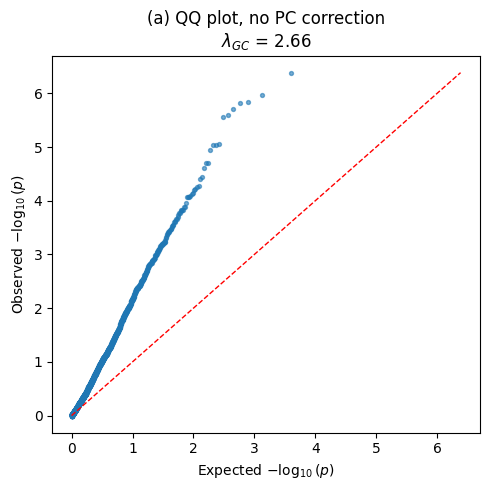

Genomic inflation factor lambda_GC = 2.662
Bonferroni threshold = 0.05/2000 = 2.50e-05
Number of SNPs significant at alpha=0.05 (Bonferroni): 14


In [4]:
import statsmodels.api as sm
from scipy.stats import chi2

M = X.shape[1]  # number of SNPs

# --- Run a univariate linear regression phenotype ~ SNP_j for every SNP ---
pvals_a = np.empty(M)
for j in range(M):
    Xj = sm.add_constant(X[:, j])          # design matrix: [intercept, SNP_j]
    res = sm.OLS(y, Xj).fit()
    pvals_a[j] = res.pvalues[1]            # p-value of the SNP coefficient


def qq_plot(pvals, ax, title):
    """QQ plot of -log10 p-values against the expected uniform null."""
    pvals = np.sort(pvals)
    n = len(pvals)
    expected = -np.log10((np.arange(1, n + 1) - 0.5) / n)   # quantiles of Uniform(0,1)
    observed = -np.log10(pvals)
    ax.scatter(expected, observed, s=8, alpha=0.6)
    lim = max(expected.max(), observed.max())
    ax.plot([0, lim], [0, lim], 'r--', lw=1)                # y = x (no inflation)
    ax.set_xlabel('Expected $-\\log_{10}(p)$')
    ax.set_ylabel('Observed $-\\log_{10}(p)$')
    ax.set_title(title)


# Genomic inflation factor (lambda_GC): median observed chi-sq / median expected
lam_a = np.median(chi2.isf(pvals_a, df=1)) / chi2.ppf(0.5, df=1)

# Bonferroni correction to control the FWER at alpha = 0.05
alpha = 0.05
bonf_thresh = alpha / M
n_sig_a = np.sum(pvals_a < bonf_thresh)

fig, ax = plt.subplots(figsize=(5, 5))
qq_plot(pvals_a, ax, f'(a) QQ plot, no PC correction\n$\\lambda_{{GC}}$ = {lam_a:.2f}')
plt.tight_layout()
plt.show()

print(f'Genomic inflation factor lambda_GC = {lam_a:.3f}')
print(f'Bonferroni threshold = {alpha}/{M} = {bonf_thresh:.2e}')
print(f'Number of SNPs significant at alpha=0.05 (Bonferroni): {n_sig_a}')

**Answer (a).** Yes, the p-values are strongly inflated: the QQ plot lifts off the $y=x$ line almost immediately and the genomic inflation factor is $\lambda_{GC}\approx 2.66$ (well above 1), so far more SNPs look "associated" than the null would predict. **14 SNPs** pass the Bonferroni threshold ($0.05/2000 = 2.5\times10^{-5}$). Because of the uncorrected population stratification, most of these are expected to be false positives rather than true causal associations.

Part (b): PCA

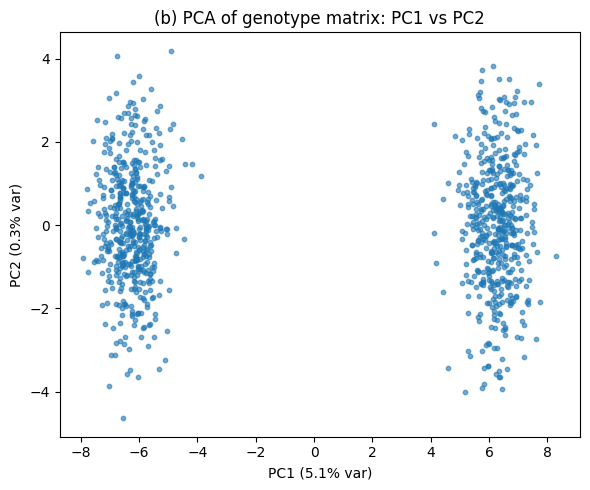

Explained variance ratio (top 5 PCs): [0.051  0.0028 0.0027 0.0027 0.0027]


In [5]:
from sklearn.decomposition import PCA

# Perform PCA on the genotype matrix
pca = PCA(n_components=10)
pcs = pca.fit_transform(X)   # (1000, 10) principal component scores

# Plot PC1 against PC2
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(pcs[:, 0], pcs[:, 1], s=10, alpha=0.6)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('(b) PCA of genotype matrix: PC1 vs PC2')
plt.tight_layout()
plt.show()

print('Explained variance ratio (top 5 PCs):',
      np.round(pca.explained_variance_ratio_[:5], 4))

**Answer (b).** PC1 dominates (it explains ~5% of the variance, an order of magnitude more than every other PC, which sit near ~0.3%), and along PC1 the individuals fall into **two clearly separated clusters** of roughly 500 each, with no further sub-structure along PC2. So under the one-individual-one-population assumption, there are **2 populations** in the dataset, and PC1 is the axis that captures this population structure.

Part (c): Linear Regression w/terms for PCA

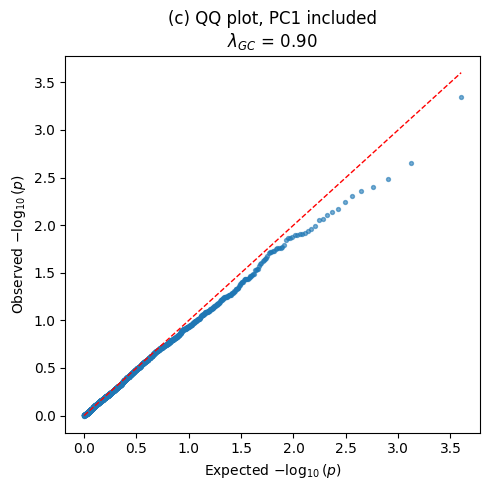

Genomic inflation factor lambda_GC = 0.895
Bonferroni threshold = 0.05/2000 = 2.50e-05
Number of SNPs significant at alpha=0.05 (Bonferroni): 0


In [6]:
# --- Re-run each regression, now including PC1 as a covariate ---
# phenotype ~ SNP_j + PC1   (PC1 "explains away" the population structure)
pc1 = pcs[:, 0]
pvals_c = np.empty(M)
for j in range(M):
    Xj = sm.add_constant(np.column_stack([X[:, j], pc1]))  # [intercept, SNP_j, PC1]
    res = sm.OLS(y, Xj).fit()
    pvals_c[j] = res.pvalues[1]                            # p-value of the SNP coefficient

lam_c = np.median(chi2.isf(pvals_c, df=1)) / chi2.ppf(0.5, df=1)
n_sig_c = np.sum(pvals_c < bonf_thresh)

fig, ax = plt.subplots(figsize=(5, 5))
qq_plot(pvals_c, ax, f'(c) QQ plot, PC1 included\n$\\lambda_{{GC}}$ = {lam_c:.2f}')
plt.tight_layout()
plt.show()

print(f'Genomic inflation factor lambda_GC = {lam_c:.3f}')
print(f'Bonferroni threshold = {alpha}/{M} = {bonf_thresh:.2e}')
print(f'Number of SNPs significant at alpha=0.05 (Bonferroni): {n_sig_c}')

**Answer (c).** After adding PC1 as a covariate, the QQ plot collapses back onto the $y=x$ line and the inflation factor drops to $\lambda_{GC}\approx 0.90$ (essentially 1, no longer inflated). Now **0 SNPs** are significant at $\alpha=0.05$ after Bonferroni correction. Conditioning on PC1 "explains away" the population stratification, so the spurious associations seen in part (a) disappear — they were driven by the population structure, not by true SNP–phenotype effects.